In [2]:
import jax
from jax import lax
import jax.numpy as jnp
import jax.profiler
import jax.scipy as jsp

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

In [3]:
def gen_wdh_image(x, y, beta, h0, sigma_up, sigma_down,
                    PA_deg, x0, y0, fwhm,
                    gamma):
    """

    """
    R1 = 6 #At pixel scale 0.012"/pixel this is the IWA at g', about 4 lamb/D
    # Rotate to wind PA
    PA_rad = -jnp.deg2rad(PA_deg)
    x_rot =  jnp.sin(PA_rad) * x + jnp.cos(PA_rad) * y
    y_rot =  jnp.cos(PA_rad) * x - jnp.sin(PA_rad) * y


    r_norm = jnp.sqrt((x_rot)**2 + (y_rot)**2)
    r_shift = jnp.sqrt((x_rot - x0)**2 + (y_rot - y0)**2)

    sigma_safe = np.where(x_rot > 0, np.maximum(sigma_up, 1e-6), np.maximum(sigma_down, 1e-6))

    # Base intensity
    power_law = (1. / r_shift)**beta
    exp_term = jnp.exp(-0.5 * (((r_shift)**2 / (h0 * (x_rot - x0)**2)**gamma) + (x_rot / sigma_safe)**2))
    I = power_law * exp_term
    # I = exp_term
    I_nanless = I.at[jnp.isnan(I)].set(0.0)
    I_valid = I_nanless.at[jnp.isinf(I_nanless)].set(0.0)


    I_coron = I_valid.at[r_norm < R1].set(0.0)


    # # Gaussian convolution
    # if fwhm is not None and fwhm > 0:
    #     sigma_pix = fwhm / (2 * jnp.sqrt(2 * jnp.log(2)))
    #     sig2 = 2 * sigma_pix * sigma_pix
    #     window = jnp.exp(-(x**2 + y**2) / sig2)
    #     I_image = jsp.signal.convolve2d(I_coron,window, mode='same')
    # else:
        # I_image = I_coron

    return I_coron

In [4]:
def plot_wdh_image(image, x_vals, y_vals, stretch='log', vmin=None, vmax=None, title=None):
    """

    """
    stretched_image = np.copy(image)

    if stretch == 'log':
        epsilon = 1e-10
        stretched_image = np.log10(stretched_image + epsilon)
        if vmin is not None:
            vmin = np.log10(vmin + epsilon)
        if vmax is not None:
            vmax = np.log10(vmax + epsilon)
    elif stretch == 'sqrt':
        stretched_image = np.sqrt(stretched_image)

    extent = [x_vals[0], x_vals[-1], y_vals[0], y_vals[-1]]
    plt.imshow(
        stretched_image, 
        origin='lower',
        extent=extent,
        vmin=vmin, vmax=vmax,
        # cmap='jet',
        cmap='Blues_r',
        )
    plt.colorbar(label='Intensity' + (f" ({stretch})" if stretch != 'linear' else ''))
    plt.xlabel('x')
    plt.ylabel('y')
    if title:
        plt.title(title)
    plt.show()

In [5]:
# Read in test model
test_model = fits.getdata("/Users/jkueny/projects/debrisdisk_freeform_fit_and_plot/starting_models/wdh_camsci2_z_20230309_10.fits")


# Define coordinate grid

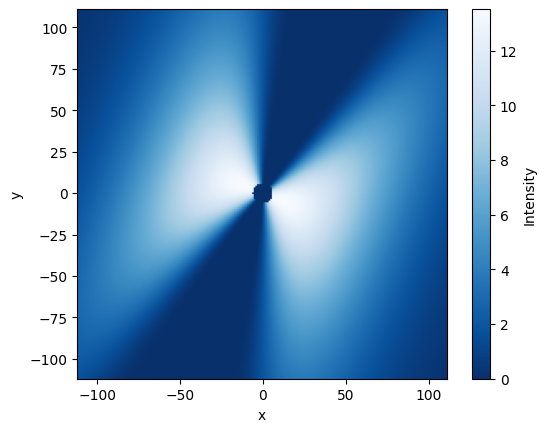

In [38]:
# Define coordinate grid
x_vals = jnp.linspace(-112, 111, 224)
y_vals = jnp.linspace(-112, 111, 224)
# print(x_vals[110:120])
# print(y_vals)
x, y = jnp.meshgrid(x_vals, y_vals)

fwhm = 3.0
Norm = 20

test_wdh = gen_wdh_image(x, y, beta=0.0, h0=0.85, sigma_up=50, sigma_down=50, PA_deg=68., 
                         x0=0.0, y0=0.0, fwhm=fwhm, gamma=1.1)

wdh_image = np.asarray(test_wdh * Norm)

plot_wdh_image(wdh_image, x_vals, y_vals, stretch="linear")
# plot_wdh_image(wdh_image, x_vals, y_vals, stretch="log")
# residuals = test_model - wdh_image
# plot_wdh_image(residuals, x_vals, y_vals, stretch="linear")
